# Stored ≥ Used: is there info in the state the model doesn't read? (notebook 4)

**used** = model recall (the state's own C-read) — what mamba2 actually retrieves.
**stored** = what an *optimal* read-out can recover from the recurrent state. Associative read-out is
**bilinear** in `(state, key)`, so we train a **bilinear probe** `value = readout(state ⊗ φθ(key))` with a
**learnable key projection** `φθ` (this fixes the earlier failure — random key features ignored the
model's `B/C` addressing and read at chance).

**Question:** does `stored ≥ used`, and does a **gap open under overload** (large `N`, where recall
collapses but the info may still be in the state)? A positive gap ⇒ the state has capacity the model's
single C-read leaves on the table (motivates better read-out / routing).

**Also — the flip (architecture comparison).** Per-state **capacity** `C = max # keys at recall ≥ τ`,
normalized by **state size** (matched memory), is a **compression ratio** that ranks *update rules* by
how well their recurrence uses memory. We compute it for **`mamba2-370m` (SSD)** and
**`gdn-340m` (gated delta rule)** and tabulate `C` and `bits / state-float`. (Hint from nb1: GDN has
higher eRank on MQAR → delta rule may compress better; this quantifies it.)

## 0. Setup

In [1]:
import os, sys, json, math
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from sklearn.random_projection import SparseRandomProjection
sys.path.insert(0, os.getcwd())
from capacity_utils import DEVICE, load_bundle, S1_erank
RESULTS_DIR = os.path.join(os.getcwd(), "stored_vs_used_results"); os.makedirs(RESULTS_DIR, exist_ok=True)
torch.manual_seed(0); np.random.seed(0)
print("device:", DEVICE, "| results ->", RESULTS_DIR)

device: cuda | results -> /home/sohyung/SSM_Rank_Analysis/notebooks/stored_vs_used_results


## 1. MQAR instances + state feature

In [2]:
KEY_OFF, VAL_OFF, VOCAB_V = 1000, 5000, 64
def make_instance(N, seed):
    rng = np.random.default_rng(seed)
    keys = rng.choice(4000, size=N, replace=False) + KEY_OFF
    vcls = rng.integers(0, VOCAB_V, size=N)
    vals = vcls + VAL_OFF
    pairs = np.empty(2 * N, dtype=np.int64); pairs[0::2] = keys; pairs[1::2] = vals
    return {"keys": keys, "vcls": vcls,
            "pairs": torch.tensor(pairs, dtype=torch.long).unsqueeze(0),
            "with_queries": torch.tensor(np.concatenate([pairs, keys]), dtype=torch.long).unsqueeze(0)}

def state_vector(bundle, ids):
    st = bundle.states(ids)
    return np.concatenate([v.numpy().reshape(-1) for v in st.values()]).astype(np.float32)

def get_embedding(bundle):
    m = bundle.model
    try:
        return m.get_input_embeddings().weight.detach().cpu().float().numpy()   # transformers/fla (GDN)
    except Exception:
        return m.backbone.embedding.weight.detach().cpu().float().numpy()        # mamba_ssm

def state_size_floats(bundle):
    st = bundle.states(make_instance(4, 0)["pairs"])
    return int(sum(int(np.prod(v.shape)) for v in st.values()))

## 2. used = model recall (C-read)

In [3]:
@torch.no_grad()
def model_recall(bundle, N, n_inst=40, seed=0):
    val_ids = torch.arange(VAL_OFF, VAL_OFF + VOCAB_V, device=DEVICE); hits = tot = 0
    for i in range(n_inst):
        inst = make_instance(N, seed * 100000 + i)
        logits = bundle.logits(inst["with_queries"])[0]
        pred = logits[2 * N + np.arange(N)][:, val_ids].argmax(-1).cpu().numpy()
        hits += int((pred == inst["vcls"]).sum()); tot += N
    return hits / tot

## 3. stored = bilinear probe with learnable key projection
`φθ(key)` = learnable linear map of the key embedding; read-out is linear on the `(state ⊗ φθ(key))`
outer product. Trained by cross-entropy over many instances (state is shared across an instance's keys).

In [4]:
class BilinearProbe(nn.Module):
    def __init__(self, h_dim, d_model, k_dim, V):
        super().__init__()
        self.kproj = nn.Linear(d_model, k_dim, bias=False)
        self.readout = nn.Linear(h_dim * k_dim, V)
    def forward(self, h, kemb):                       # h:(B,h_dim)  kemb:(B,d_model)
        kf = self.kproj(kemb)                         # (B,k_dim)
        x = torch.bmm(h.unsqueeze(2), kf.unsqueeze(1)).flatten(1)   # (B, h_dim*k_dim)
        return self.readout(x)

def run_stored(bundle, N, n_train=150, n_test=50, h_dim=512, k_dim=32, steps=400, seed=0):
    insts = [make_instance(N, seed * 100000 + i) for i in range(n_train + n_test)]
    d_full = state_vector(bundle, insts[0]["pairs"]).shape[0]
    srp = SparseRandomProjection(n_components=h_dim, random_state=0); srp.fit(np.zeros((1, d_full)))
    emb = get_embedding(bundle)

    def build(split):
        H, K, Y = [], [], []
        for inst in split:
            h = srp.transform(state_vector(bundle, inst["pairs"]).reshape(1, -1))[0]
            for j in range(N):
                H.append(h); K.append(emb[inst["keys"][j]]); Y.append(inst["vcls"][j])
        return (torch.tensor(np.array(H), dtype=torch.float32, device=DEVICE),
                torch.tensor(np.array(K), dtype=torch.float32, device=DEVICE),
                torch.tensor(np.array(Y), dtype=torch.long, device=DEVICE))
    Htr, Ktr, Ytr = build(insts[:n_train]); Hte, Kte, Yte = build(insts[n_train:])
    probe = BilinearProbe(h_dim, emb.shape[1], k_dim, VOCAB_V).to(DEVICE)
    opt = torch.optim.Adam(probe.parameters(), lr=1e-3, weight_decay=1e-5)
    lossf = nn.CrossEntropyLoss()
    for _ in range(steps):
        opt.zero_grad(); loss = lossf(probe(Htr, Ktr), Ytr); loss.backward(); opt.step()
    with torch.no_grad():
        acc = (probe(Hte, Kte).argmax(-1) == Yte).float().mean().item()
    return acc

## 4. Sweep N: stored vs used (+ eRank), and the gap

In [5]:
import gc
MODELS = ["mamba2-370m", "gdn-340m"]
N_GRID = [4, 8, 16, 32, 64, 128]
results, state_floats = {}, {}
for mname in MODELS:
    try:
        bundle = load_bundle(mname)
    except Exception as e:
        print("skip", mname, "->", type(e).__name__, str(e)[:120]); continue
    state_floats[mname] = state_size_floats(bundle)
    rows = []
    for N in N_GRID:
        used = model_recall(bundle, N)
        stored = run_stored(bundle, N)
        er = float(np.mean([S1_erank(bundle, make_instance(N, i)["pairs"])["erank_mean"] for i in range(5)]))
        rows.append({"N": N, "used": used, "stored": stored, "gap": stored - used, "erank": er})
        print(f"{mname:12s} N={N:>3} used={used:.3f} stored={stored:.3f} gap={stored-used:+.3f} eRank={er:.2f}")
    results[mname] = rows
    del bundle; gc.collect(); torch.cuda.empty_cache()
with open(os.path.join(RESULTS_DIR, "stored_vs_used.json"), "w") as f:
    json.dump({"chance": 1.0 / VOCAB_V, "state_floats": state_floats, "results": results}, f, indent=2)

/data2/sohyung/conda-envs/sh_infocap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mamba2-370m  N=  4 used=0.944 stored=0.025 gap=-0.919 eRank=3.15


mamba2-370m  N=  8 used=0.919 stored=0.012 gap=-0.906 eRank=4.21


mamba2-370m  N= 16 used=0.922 stored=0.020 gap=-0.902 eRank=5.26


mamba2-370m  N= 32 used=0.874 stored=0.014 gap=-0.860 eRank=5.86


...

gdn-340m     N=  8 used=0.925 stored=0.015 gap=-0.910 eRank=4.43


gdn-340m     N= 16 used=0.859 stored=0.021 gap=-0.838 eRank=7.34


gdn-340m     N= 32 used=0.816 stored=0.016 gap=-0.801 eRank=11.02


gdn-340m     N= 64 used=0.779 stored=0.017 gap=-0.762 eRank=17.11


gdn-340m     N=128 used=0.615 stored=0.017 gap=-0.597 eRank=23.35


In [6]:
# 4.1 COMPRESSION-RATIO comparison table: capacity C = max N with acc>=tau (linear-interp crossing)
def cap_interp(rows, key, tau):
    xs = [r["N"] for r in rows]; ys = [r[key] for r in rows]
    if ys[0] < tau: return 0.0
    for i in range(len(xs) - 1):
        if ys[i] >= tau >= ys[i + 1]:
            f = (ys[i] - tau) / (ys[i] - ys[i + 1] + 1e-9); return xs[i] + f * (xs[i + 1] - xs[i])
    return float(xs[-1])                      # never dropped below tau in grid -> lower bound

bpk = math.log2(VOCAB_V)                        # bits per key
comp = {}
print(f"{'model':12s}{'state Mfloat':>13}{'C_used@.9':>11}{'C_used@.5':>11}{'C_stored@.9':>12}{'used bits/Mfloat':>17}")
for m in results:
    sf = state_floats[m] / 1e6
    cu9 = cap_interp(results[m], "used", 0.9); cu5 = cap_interp(results[m], "used", 0.5)
    cs9 = cap_interp(results[m], "stored", 0.9)
    ratio = cu9 * bpk / sf                       # recalled bits per 1M state floats (@0.9)
    comp[m] = {"state_Mfloat": sf, "C_used@0.9": cu9, "C_used@0.5": cu5, "C_stored@0.9": cs9,
               "used_bits_per_Mfloat": ratio}
    print(f"{m:12s}{sf:>13.2f}{cu9:>11.1f}{cu5:>11.1f}{cs9:>12.1f}{ratio:>17.2f}")
with open(os.path.join(RESULTS_DIR, "compression_table.json"), "w") as f:
    json.dump(comp, f, indent=2)

model        state Mfloat  C_used@.9  C_used@.5 C_stored@.9 used bits/Mfloat
mamba2-370m         12.58       23.3      128.0         0.0            11.13
gdn-340m            31.46       11.0      128.0         0.0             2.11


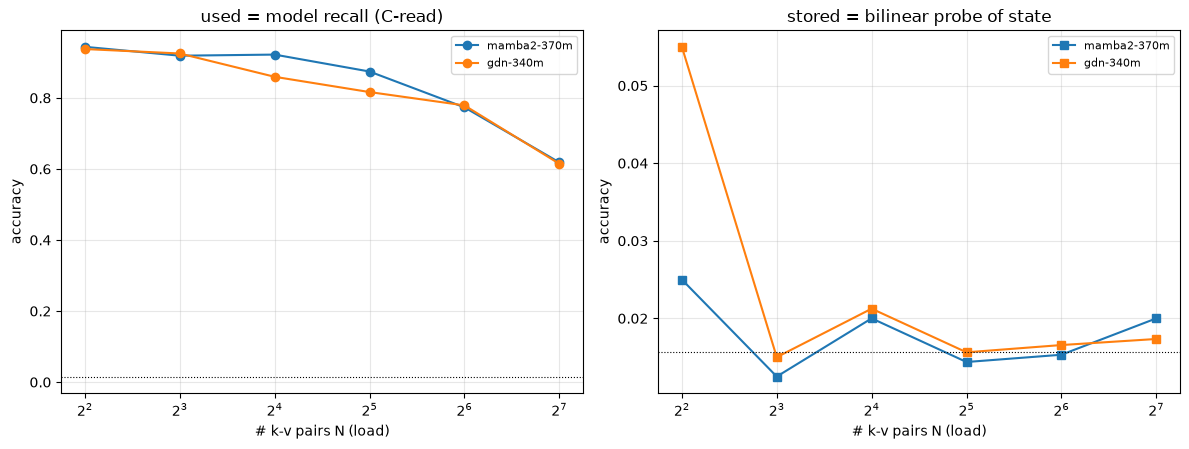

Per-state capacity C = max keys at recall>=tau. Compression ratio = C·log2(V) / state-floats; compare across update rules at matched state size (see table). gap = stored-used shows read headroom.


In [7]:
# 4.2 curves: used & stored vs N, both models
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for m in results:
    N = [r["N"] for r in results[m]]
    ax[0].plot(N, [r["used"] for r in results[m]], "o-", label=m)
    ax[1].plot(N, [r["stored"] for r in results[m]], "s-", label=m)
for a, t in zip(ax, ["used = model recall (C-read)", "stored = bilinear probe of state"]):
    a.axhline(1 / VOCAB_V, color="k", ls=":", lw=.8)
    a.set_xscale("log", base=2); a.set_xlabel("# k-v pairs N (load)"); a.set_ylabel("accuracy")
    a.set_title(t); a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "stored_vs_used.png"), dpi=120); plt.show()
print("Per-state capacity C = max keys at recall>=tau. Compression ratio = C·log2(V) / state-floats; "
      "compare across update rules at matched state size (see table). gap = stored-used shows read headroom.")

## 5. Interpretation
**gap = stored − used:**
- **gap ≈ 0** ⇒ the model already reads ~all a linear/bilinear read-out can → capacity is genuinely
  read-limited by what's stored; per-chunk capacity ≈ used-recall.
- **gap > 0, widening with N** ⇒ under overload the state still holds associations the single C-read
  can't surface → headroom for a better read-out / multi-read / routing (relevant to the multi-query
  "found-but-not-retrieved" failure and to (3) SSC reuse).

**Compression-ratio table (the architecture comparison):** per-state capacity `C` and `bits/Mfloat` at
matched state size rank the update rules — higher = the recurrence packs more retrievable associations
per unit memory. This is the make-or-break number for the routing methodology: it only beats a KV cache
if one frozen state serves `C ≫ 1` keys.

Caveats: `stored` is a *lower bound* (random-projected state + learned linear key map; a per-layer probe
or recurrent-state SAE could widen it); capacities read off a coarse N grid; models compared at their
native (unequal) state sizes — the `bits/Mfloat` column does the size normalization.